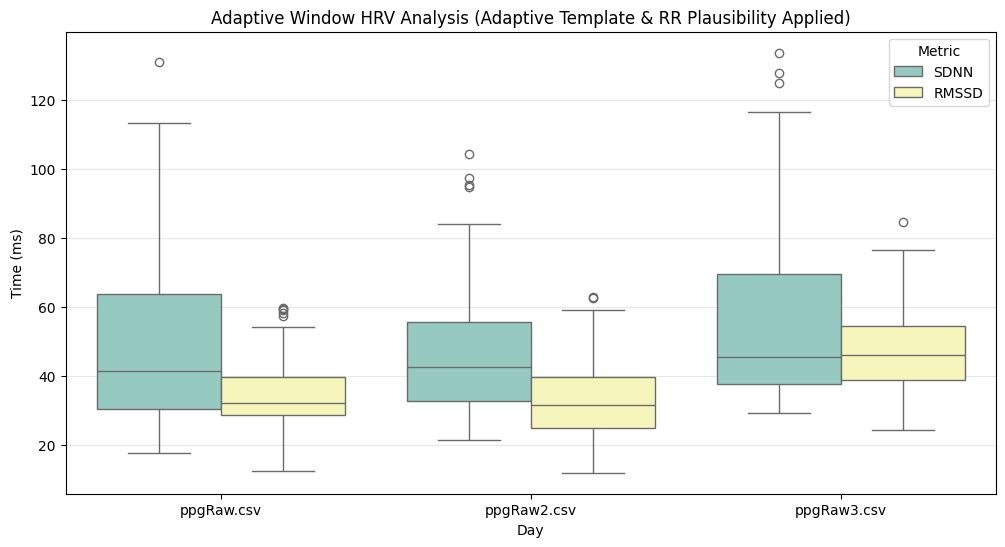

In [3]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

FS = 200

def preprocess_signal(file_path):
    try:
        df = pd.read_csv(file_path, header=None)
        raw_sig = pd.to_numeric(df.iloc[:, 1], errors='coerce').fillna(0).values
    except: return np.array([])

    if len(raw_sig) < 2000: return np.array([])
    raw_sig = raw_sig[1000:] # 초기 안정화 5초 제거

    # Bandpass Filter (0.5 - 4Hz)
    nyq = 0.5 * FS
    b, a = signal.butter(3, [0.5/nyq, 4.0/nyq], btype='bandpass')
    filtered_sig = signal.filtfilt(b, a, raw_sig)

    # Detrending
    trend = pd.Series(filtered_sig).rolling(window=int(FS*1.5), center=True, min_periods=1).mean()
    return filtered_sig - trend.fillna(0).values

def get_adaptive_hrv(sig, win_size_sec=300):
    """
    보완 A & B 반영: 구간별 적응형 템플릿 및 RR 타당성 검사
    """
    step_size = win_size_sec * FS
    results = []

    for start in range(0, len(sig) - step_size, step_size):
        segment = sig[start : start + step_size]
        peaks, _ = signal.find_peaks(segment, distance=FS*0.4, height=np.std(segment)*0.5)

        if len(peaks) < 10: continue

        # 1. 비트 추출 및 정규화
        beat_win = int(0.6 * FS)
        beats = []
        valid_indices = []
        for p in peaks:
            if p - beat_win//2 < 0 or p + beat_win//2 >= len(segment): continue
            b = segment[p - beat_win//2 : p + beat_win//2]
            b = (b - np.mean(b)) / (np.std(b) + 1e-6)
            beats.append(b)
            valid_indices.append(p)

        if not beats: continue
        beats = np.array(beats)

        # 2. Iterative Template (보완 B: 반복 업데이트)
        # 초기 중앙값 템플릿 -> 상관계수 상위 70%로 템플릿 갱신
        tmp_template = np.median(beats, axis=0)
        tmp_corrs = np.array([stats.pearsonr(b, tmp_template)[0] for b in beats])
        refined_template = np.mean(beats[tmp_corrs > np.percentile(tmp_corrs, 30)], axis=0)

        # 3. 최종 상관계수 필터링
        final_corrs = np.array([stats.pearsonr(b, refined_template)[0] for b in beats])
        mask_shape = final_corrs > 0.7

        # 4. RR Plausibility Check (보완 A: 300-1300ms + Sudden Change 필터)
        good_peaks = np.array(valid_indices)[mask_shape]
        if len(good_peaks) < 5: continue

        rr_intervals = np.diff(good_peaks) / FS * 1000

        # 물리적 범위 필터
        mask_rr = (rr_intervals > 300) & (rr_intervals < 1300)

        # Sudden change 필터 (|RR_n - RR_n-1| > 50ms 제거)
        diff_rr = np.abs(np.diff(rr_intervals))
        mask_sudden = np.insert(diff_rr < 50, 0, True) # 첫 번째 RR은 비교군 없으므로 포함

        final_rr = rr_intervals[mask_rr & mask_sudden]

        # 5. HRV 계산 (충분한 데이터 확보 시)
        if len(final_rr) > 10:
            sdnn = np.std(final_rr, ddof=1)
            rmssd = np.sqrt(np.mean(np.diff(final_rr)**2))
            results.append({'SDNN': sdnn, 'RMSSD': rmssd})

    return results

# =========================================================
# 실행 및 시각화
# =========================================================
all_data = []
file_list = [f"/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw{i}.csv" for i in ["", "2", "3"]]

for f_path in file_list:
    processed_sig = preprocess_signal(f_path)
    if len(processed_sig) == 0: continue

    hrv_metrics = get_adaptive_hrv(processed_sig)
    f_name = f_path.split('/')[-1]

    for m in hrv_metrics:
        all_data.append([f_name, 'SDNN', m['SDNN']])
        all_data.append([f_name, 'RMSSD', m['RMSSD']])

if all_data:
    df = pd.DataFrame(all_data, columns=['Day', 'Metric', 'Value'])

    # 박스플롯 출력
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Day', y='Value', hue='Metric', data=df, palette='Set3')
    plt.title("Adaptive Window HRV Analysis (Adaptive Template & RR Plausibility Applied)")
    plt.ylabel("Time (ms)")
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()
else:
    print("분석 가능한 데이터가 부족합니다.")


[/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv 진단 결과]
  > 왜도(Skewness) 수치: 0.0646
  > ✅ 판정: 신호가 [정상 (Normal)]
  > 이유: 왜도가 양수입니다. 뾰족한 피크가 위를 향하고 있습니다.
  > 조치: 코드에서 '-'를 빼고 'raw_sig' 그대로 쓰세요.


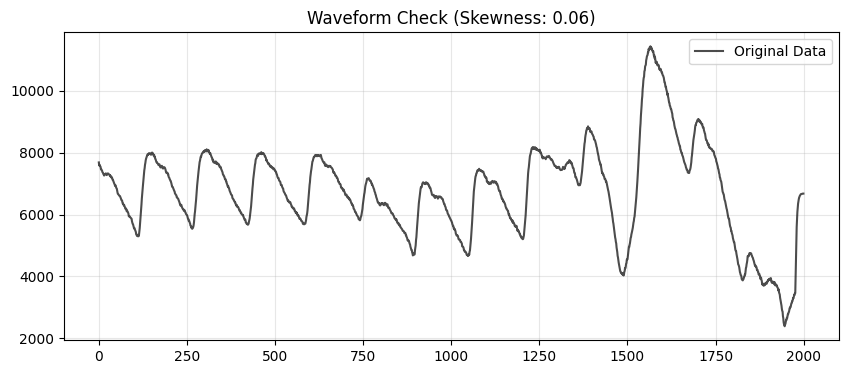

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# =========================================================
# [설정] 확인하고 싶은 파일 경로 입력
# =========================================================
file_path = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv"


def check_polarity(file_path):
    try:
        # 데이터 로드 (헤더 없음, 1번째 컬럼)
        df = pd.read_csv(file_path, header=None, usecols=[1])
        raw = pd.to_numeric(df.iloc[:, 0], errors='coerce').fillna(0).values
    except:
        print("파일을 찾을 수 없습니다.")
        return

    # 앞부분 노이즈 제거 (5초)
    if len(raw) > 1000: sig = raw[1000:3000] # 10초 분량만 샘플링
    else: sig = raw

    # 1. 왜도(Skewness) 계산
    skew_val = stats.skew(sig)

    # 2. 판정 로직
    print(f"\n[{file_path} 진단 결과]")
    print(f"  > 왜도(Skewness) 수치: {skew_val:.4f}")

    if skew_val < 0:
        print("  > 🚨 판정: 신호가 [뒤집혀 있음 (Inverted)]")
        print("  > 이유: 왜도가 음수입니다. 뾰족한 피크가 아래를 향하고 있습니다.")
        print("  > 조치: 코드에서 '-raw_sig'를 유지하세요.")
        is_inverted = True
    else:
        print("  > ✅ 판정: 신호가 [정상 (Normal)]")
        print("  > 이유: 왜도가 양수입니다. 뾰족한 피크가 위를 향하고 있습니다.")
        print("  > 조치: 코드에서 '-'를 빼고 'raw_sig' 그대로 쓰세요.")
        is_inverted = False

    # 3. 눈으로 확인 (그래프)
    plt.figure(figsize=(10, 4))
    plt.title(f"Waveform Check (Skewness: {skew_val:.2f})")
    plt.plot(sig, label='Original Data', color='black', alpha=0.7)
    if is_inverted:
        plt.plot(-sig, label='Inverted (Corrected)', color='red', linestyle='--')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

check_polarity(file_path)